### 3. Random Forest 🌳
##### working on it

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

#### 3.1 RF using full dataset

In [2]:
data_full = pd.read_csv("../COMP30027_2024_asst2_data/train_high_dim.csv")
data_full = data_full.drop(columns='id')

In [3]:
# split the data
X = data_full.drop(columns=["imdb_score_binned"])
y = data_full["imdb_score_binned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=715)

rf = RandomForestClassifier(random_state=715)

In [4]:
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

# precision and recall
precision = precision_score(y_test, predictions, average='weighted')
recall = recall_score(y_test, predictions, average='weighted')

print("Precision:", precision)
print("Recall:", recall)

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

Accuracy: 0.6356073211314476
Precision: 0.5529630103673364
Recall: 0.6356073211314476
Confusion Matrix:
 [[  0   0   6   0   0]
 [  0   0  53   1   0]
 [  0   0 365   3   0]
 [  0   0 134  17   0]
 [  0   0  17   5   0]]


C:\Users\Steven\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [5]:
# evaluate with cross validation
scores = cross_val_score(rf, X, y, cv=10)
print("Scores:", scores.mean())

Scores: 0.6464651162790698


#### 3.2 RF using dataset with feature selection

In [17]:
data = pd.read_csv("../COMP30027_2024_asst2_data/train_dataset_select.csv")
data = data.drop(columns='id')
test_data = pd.read_csv("../COMP30027_2024_asst2_data/test_dataset_select.csv")
test_data = test_data.drop(columns='id')

In [18]:
# split the data
X = data.drop(columns=["imdb_score_binned"])
y = data["imdb_score_binned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=715)

rf = RandomForestClassifier(random_state=715)

In [19]:
rf.fit(X_train, y_train)
predictions = rf.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

# precision and recall
precision = precision_score(y_test, predictions, average='weighted')
recall = recall_score(y_test, predictions, average='weighted')

print("Precision:", precision)
print("Recall:", recall)

# Generate and display the confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

Accuracy: 0.7021630615640599
Precision: 0.6657340092558126
Recall: 0.7021630615640599
Confusion Matrix:
 [[  0   1   5   0   0]
 [  0   3  50   1   0]
 [  0   5 341  22   0]
 [  0   0  81  69   1]
 [  0   0   0  13   9]]


C:\Users\Steven\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


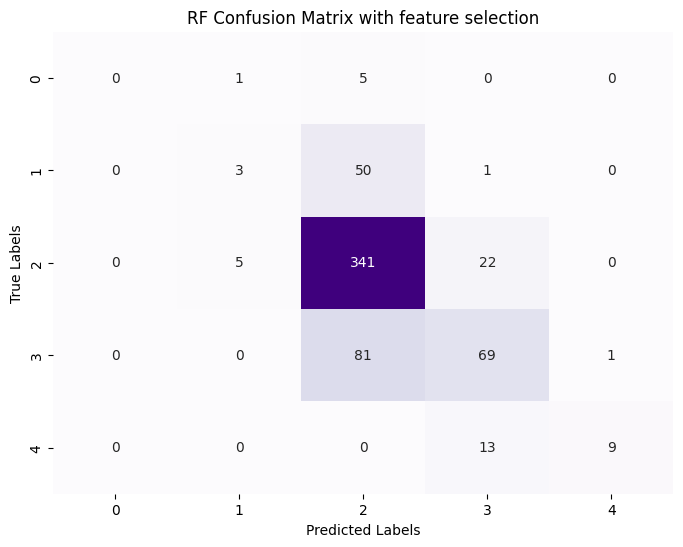

In [20]:
# plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title('RF Confusion Matrix with feature selection')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig("../COMP30027_2024_asst2_graph/RF_Confustion_Matrix_Select.png")
plt.show()

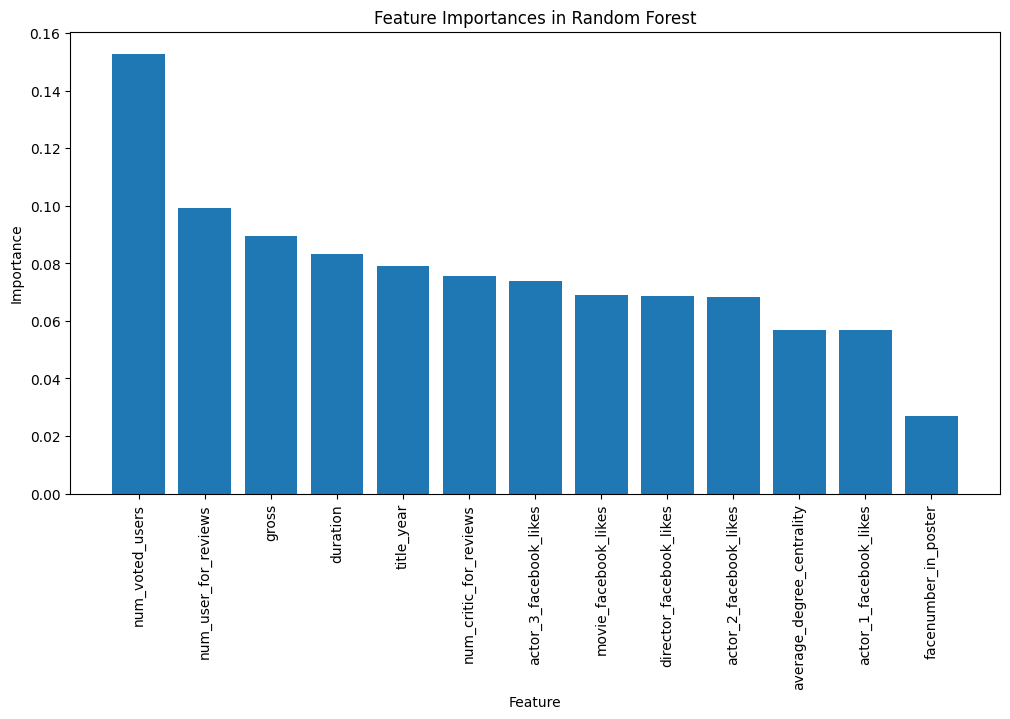

In [26]:
importances = rf.feature_importances_
feature_names = X_train.columns

# plot the importance of features
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(12, 6))
plt.title('Feature Importances in Random Forest')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

In [10]:
# evaluate with cross validation
scores = cross_val_score(rf, X, y, cv=10)
print("Scores:", scores.mean())

Scores: 0.72303211517165


#### Prediction on Kaggle dataset

In [11]:
rf = RandomForestClassifier(random_state=715)
rf.fit(X, y)

test_pred = rf.predict(test_data)
ids = range(1, len(test_pred) + 1)

# save submission file
prediction = pd.DataFrame({'id': ids, 'imdb_score_binned': test_pred})
print(prediction['imdb_score_binned'].value_counts())
prediction.to_csv("../Kaggle_submissions/RF_select.csv", index=False)

imdb_score_binned
2    525
3    199
4     21
1      7
Name: count, dtype: int64
